<a href="https://colab.research.google.com/github/SharonAwuor/Machine-Learning/blob/main/cloud_env_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/cloud_performance_features.csv")

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

In [4]:
class CloudEnvironment(gym.Env):

    def __init__(self):

        super().__init__()

In [5]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class CloudEnvironment(gym.Env):

    def __init__(self):
        super().__init__()

        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(4,),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(3)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.state = np.random.uniform(0, 100, size=(4,))

        return self.state.astype(np.float32), {}

    def step(self, action):

        reward = np.random.randn()

        self.state = np.random.uniform(0, 100, size=(4,))

        terminated = False
        truncated = False

        return (
            self.state.astype(np.float32),
            reward,
            terminated,
            truncated,
            {}
        )

In [6]:
env = CloudEnvironment()

In [7]:
state, info = env.reset()

print("Initial State:", state)

Initial State: [ 0.2263808 89.017685  88.801834  52.39833  ]


In [8]:
next_state, reward, terminated, truncated, info = env.step(1)

print("Next State:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)

Next State: [23.38196  73.27961  57.226128 14.999448]
Reward: 0.00606048581585134
Terminated: False
Truncated: False


In [9]:
state, info = env.reset()

for i in range(5):
    action = env.action_space.sample()   # Random action
    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"Step {i+1}")
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward:", reward)
    print("-" * 40)

Step 1
Action: 1
Next State: [71.13971   4.122555 92.1859   35.732826]
Reward: -0.11647007397476836
----------------------------------------
Step 2
Action: 1
Next State: [82.73972    0.9389302 50.979565  75.525375 ]
Reward: 0.2614785425024125
----------------------------------------
Step 3
Action: 0
Next State: [75.271225  58.384308   6.3440332 17.468754 ]
Reward: -0.6247249974906092
----------------------------------------
Step 4
Action: 2
Next State: [33.534718 83.80573  57.092922 20.00821 ]
Reward: -0.4792526272008413
----------------------------------------
Step 5
Action: 0
Next State: [90.69991   61.577118   4.5175357 25.85652  ]
Reward: -0.36463747768300003
----------------------------------------


In [10]:
import numpy as np

# Create the environment here
env = CloudEnvironment()

In [11]:
# Number of states (simplified examples)
num_states = 100

# Number of actions
num_actions = env.action_space.n

# Initialize Q-table
Q_table = np.zeros((num_states, num_actions))

print(Q_table.shape)

(100, 3)


In [12]:
alpha = 0.1      # Learning rate
gamma = 0.95     # Discount factor
epsilon = 1.0    # Exploration rate

episodes = 100
max_steps = 100

In [13]:
episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):

        # Convert state to an index
        state_index = int(state[0]) % num_states

        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_table[state_index])

        next_state, reward, terminated, truncated, info = env.step(action)

        next_state_index = int(next_state[0]) % num_states

        # Q-learning update
        Q_table[state_index, action] = (
            Q_table[state_index, action]
            + alpha * (
                reward
                + gamma * np.max(Q_table[next_state_index])
                - Q_table[state_index, action]
            )
        )

        state = next_state

        total_reward += reward

        if terminated or truncated:
            break

    epsilon *= 0.995

    episode_rewards.append(total_reward)

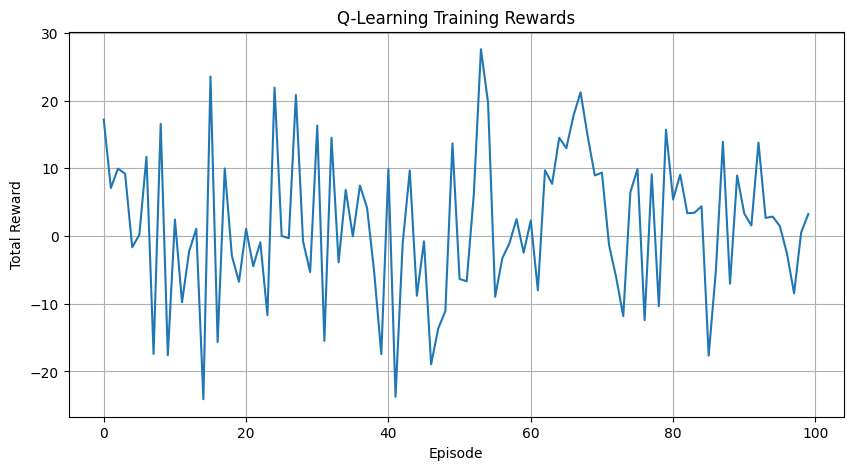

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Q-Learning Training Rewards")

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.grid(True)

plt.show()

In [15]:
print(Q_table)

[[ 0.49682823  0.47578843  0.08468268]
 [ 0.51155004  0.20247805  0.16252273]
 [ 0.13237067  0.20230022  0.4956652 ]
 [ 0.52474307  0.49859806  0.34495141]
 [ 0.72051306  0.66086185  0.48464031]
 [ 0.58258606  0.96659922  0.63491039]
 [ 0.81565078  0.11729423  0.26322628]
 [ 0.53992205  0.33260957  0.27255818]
 [ 0.7464263   0.50445497  0.72957113]
 [ 0.34430934  0.44996536  0.47013826]
 [ 0.11544229  0.79277485  0.2641454 ]
 [ 0.73068678  0.09388525  0.8520119 ]
 [ 0.84499344  0.63760453  0.73326217]
 [ 0.5118976   0.35247037  0.73845503]
 [ 0.53290469  0.24718547  0.86463876]
 [ 0.55664808  0.62105276  0.4331197 ]
 [ 0.52991216  0.84745549  0.64250788]
 [ 0.38557636  0.28552147  0.6190036 ]
 [ 1.0168201   0.40752286  0.19567435]
 [ 0.00172349  0.90149518  0.1252138 ]
 [ 0.61613787  0.56377789  0.47577421]
 [ 0.10768172  0.35714419  0.76883846]
 [ 0.27486429  0.32400226  0.58390735]
 [ 0.50585844  0.82706783  0.87823204]
 [ 0.34136176  0.49876172  0.47835702]
 [ 0.91575114  0.43549526

In [16]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/cloud_performance_features.csv")

In [17]:
state_features = [
    "cpu_usage",
    "memory_usage",
    "network_traffic",
    "power_consumption"
]

In [18]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class CloudEnvironment(gym.Env):

    def __init__(self, dataframe):

        super().__init__()

        self.df = dataframe.reset_index(drop=True)

        self.current_step = 0

        self.features = [
            "cpu_usage",
            "memory_usage",
            "network_traffic",
            "power_consumption"
        ]

        self.observation_space = spaces.Box(
            low=0,
            high=1000,
            shape=(4,),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(3)

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0

        state = self.df.loc[self.current_step, self.features].values

        return state.astype(np.float32), {}

    def step(self, action):

        row = self.df.iloc[self.current_step]

        execution_time = row["execution_time"]
        energy_efficiency = row["energy_efficiency"]
        power = row["power_consumption"]

        # Reward Function
        reward = (
            energy_efficiency
            - (execution_time / 100)
            - (power / 500)
        )

        self.current_step += 1

        terminated = self.current_step >= len(self.df) - 1

        truncated = False

        if terminated:
            next_state = np.zeros(4)

        else:
            next_state = self.df.loc[
                self.current_step,
                self.features
            ].values

        return (
            next_state.astype(np.float32),
            reward,
            terminated,
            truncated,
            {}
        )

In [19]:
env = CloudEnvironment(df)

In [20]:
state, info = env.reset()

print(state)

[ 54.88135  78.95086 164.77597 287.809  ]


In [21]:
next_state, reward, terminated, truncated, info = env.step(1)

print("Next State:", next_state)
print("Reward:", reward)

Next State: [ 71.518936  29.901882 500.0076   362.27356 ]
Reward: -0.7154847085698656


In [22]:
env = CloudEnvironment(df)

In [23]:
import numpy as np

num_states = 100
num_actions = env.action_space.n

Q_table = np.zeros((num_states, num_actions))

print(Q_table.shape)

(100, 3)


In [24]:
alpha = 0.1          # Learning rate
gamma = 0.95         # Discount factor
epsilon = 1.0        # Exploration rate

episodes = 100
max_steps = 500

In [25]:
episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):

        # Convert the first state value into a table index
        state_index = int(state[0]) % num_states

        # Epsilon-greedy policy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_table[state_index])

        next_state, reward, terminated, truncated, info = env.step(action)

        next_state_index = int(next_state[0]) % num_states

        # Q-learning update
        Q_table[state_index, action] += alpha * (
            reward
            + gamma * np.max(Q_table[next_state_index])
            - Q_table[state_index, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    epsilon = max(0.01, epsilon * 0.995)

    episode_rewards.append(total_reward)

print("Training Complete!")

Training Complete!


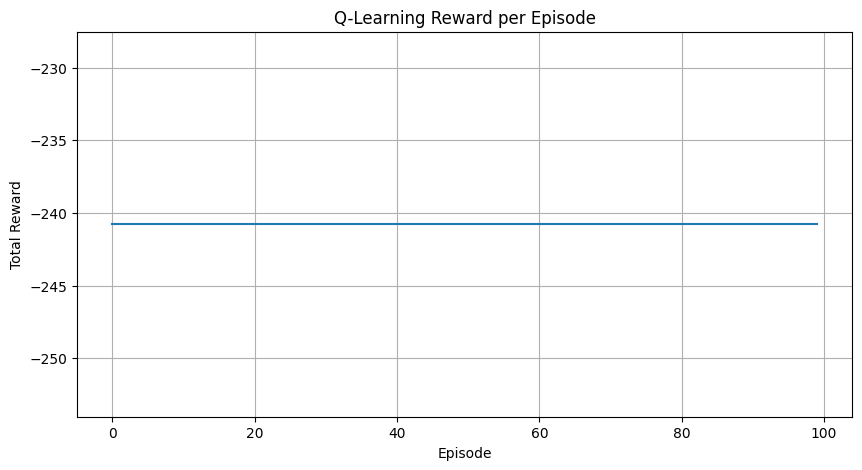

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(episode_rewards)
plt.title("Q-Learning Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [27]:
print(Q_table[:10])

[[-3.54063854 -3.52054577 -3.62130314]
 [-4.51857292 -4.54923619 -4.50960356]
 [-4.8928051  -4.85371853 -4.96288591]
 [-5.4973352  -5.52720822 -5.51532075]
 [-4.17861156 -4.09665474 -4.11740205]
 [-5.22478775 -5.14642475 -5.2554181 ]
 [-4.86290557 -5.13018691 -4.68076067]
 [-5.08560341 -5.21522603 -5.24882983]
 [-4.71994747 -4.85794769 -4.76257653]
 [-5.26249224 -5.24713099 -5.0601576 ]]


In [28]:
!pip install stable-baselines3 gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 6.0 MB/s eta 0:00:00


In [29]:
from stable_baselines3 import DQN

import numpy as np
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
env = CloudEnvironment(df)

In [31]:
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.001,
    buffer_size=10000,
    learning_starts=100,
    batch_size=32,
    gamma=0.99,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
model.learn(
    total_timesteps=10000
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
obs, info = env.reset()

total_reward = 0

for i in range(100):

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    if terminated or truncated:
        break

print("Total Reward:", total_reward)

Total Reward: -50.059996684705894


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
model.save("dqn_cloud_resource_optimizer")